In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
path = Path("/Volumes/LaCie/sensitivity/axial_paper_3")
with xr.open_dataset(path / "sle.nc") as f:
    sle = f.sle

FileNotFoundError: [Errno 2] No such file or directory: b'/Volumes/LaCie/sensitivity/axial_paper_3/sle.nc'

In [ ]:
thkdir = path / "combined"
files = list(thkdir.glob("*.nc"))
ds = xr.open_mfdataset(files, combine="nested", concat_dim="run", parallel=True)
thk = ds.thickness
initthk = thk.isel(time=0, run=0).compute()

dthk = thk.isel(time=-1) - thk.isel(time=0)
avg = dthk.mean(dim="run").compute()
std = dthk.std(dim="run").compute()

avg = avg.where(initthk > 0)
std = std.where(initthk > 0)

In [ ]:
import cartopy.crs as ccrs

def make_figure(height_ratio, ax_size=2.0, cb_thickness=0.1, cb_pad=0.15,
                 wspace=0.4, hspace=0.5,
                 left=0.7, right=0.3, top=0.3, bottom=0.6,
                 bar_width=0.4, bar_pad=0.3):
    """
    ...
    bar_width : width (inches) of the range-bar axis to the right of ax_top
    bar_pad   : gap (inches) between ax_top and the bar axis
    """
    kw = dict(central_latitude=-90, central_longitude=0, true_scale_latitude=-70)
    proj = ccrs.Stereographic(**kw)

    top_h = height_ratio * ax_size
    bottom_cell_h = ax_size + cb_pad + cb_thickness
    top_row_w = 2 * ax_size + wspace  # total width available to top row (matches bottom row)

    W = left + top_row_w + right
    H = top + top_h + hspace + bottom_cell_h + bottom

    fig = plt.figure(figsize=(W, H), dpi=300)
    fx, fy = lambda v: v / W, lambda v: v / H

    top_y = bottom + bottom_cell_h + hspace
    ax_top_w = top_row_w - bar_pad - bar_width

    ax_top = fig.add_axes([fx(left), fy(top_y), fx(ax_top_w), fy(top_h)])

    x_bar = left + ax_top_w + bar_pad
    ax_bar = fig.add_axes([fx(x_bar), fy(top_y), fx(bar_width), fy(top_h)], sharey=ax_top)

    ax_bl = fig.add_axes([fx(left), fy(bottom + cb_pad + cb_thickness),
                           fx(ax_size), fy(ax_size)], projection=proj)
    cax_bl = fig.add_axes([fx(left)+fx(ax_size)/4, fy(bottom), fx(ax_size)/2, fy(cb_thickness)])

    x_br = left + ax_size + wspace
    ax_br = fig.add_axes([fx(x_br), fy(bottom + cb_pad + cb_thickness),
                           fx(ax_size), fy(ax_size)], projection=proj)
    cax_br = fig.add_axes([fx(x_br) + fx(ax_size)/4, fy(bottom), fx(ax_size)/2, fy(cb_thickness)])

    return fig, ax_top, ax_bar, ax_bl, ax_br, cax_bl, cax_br

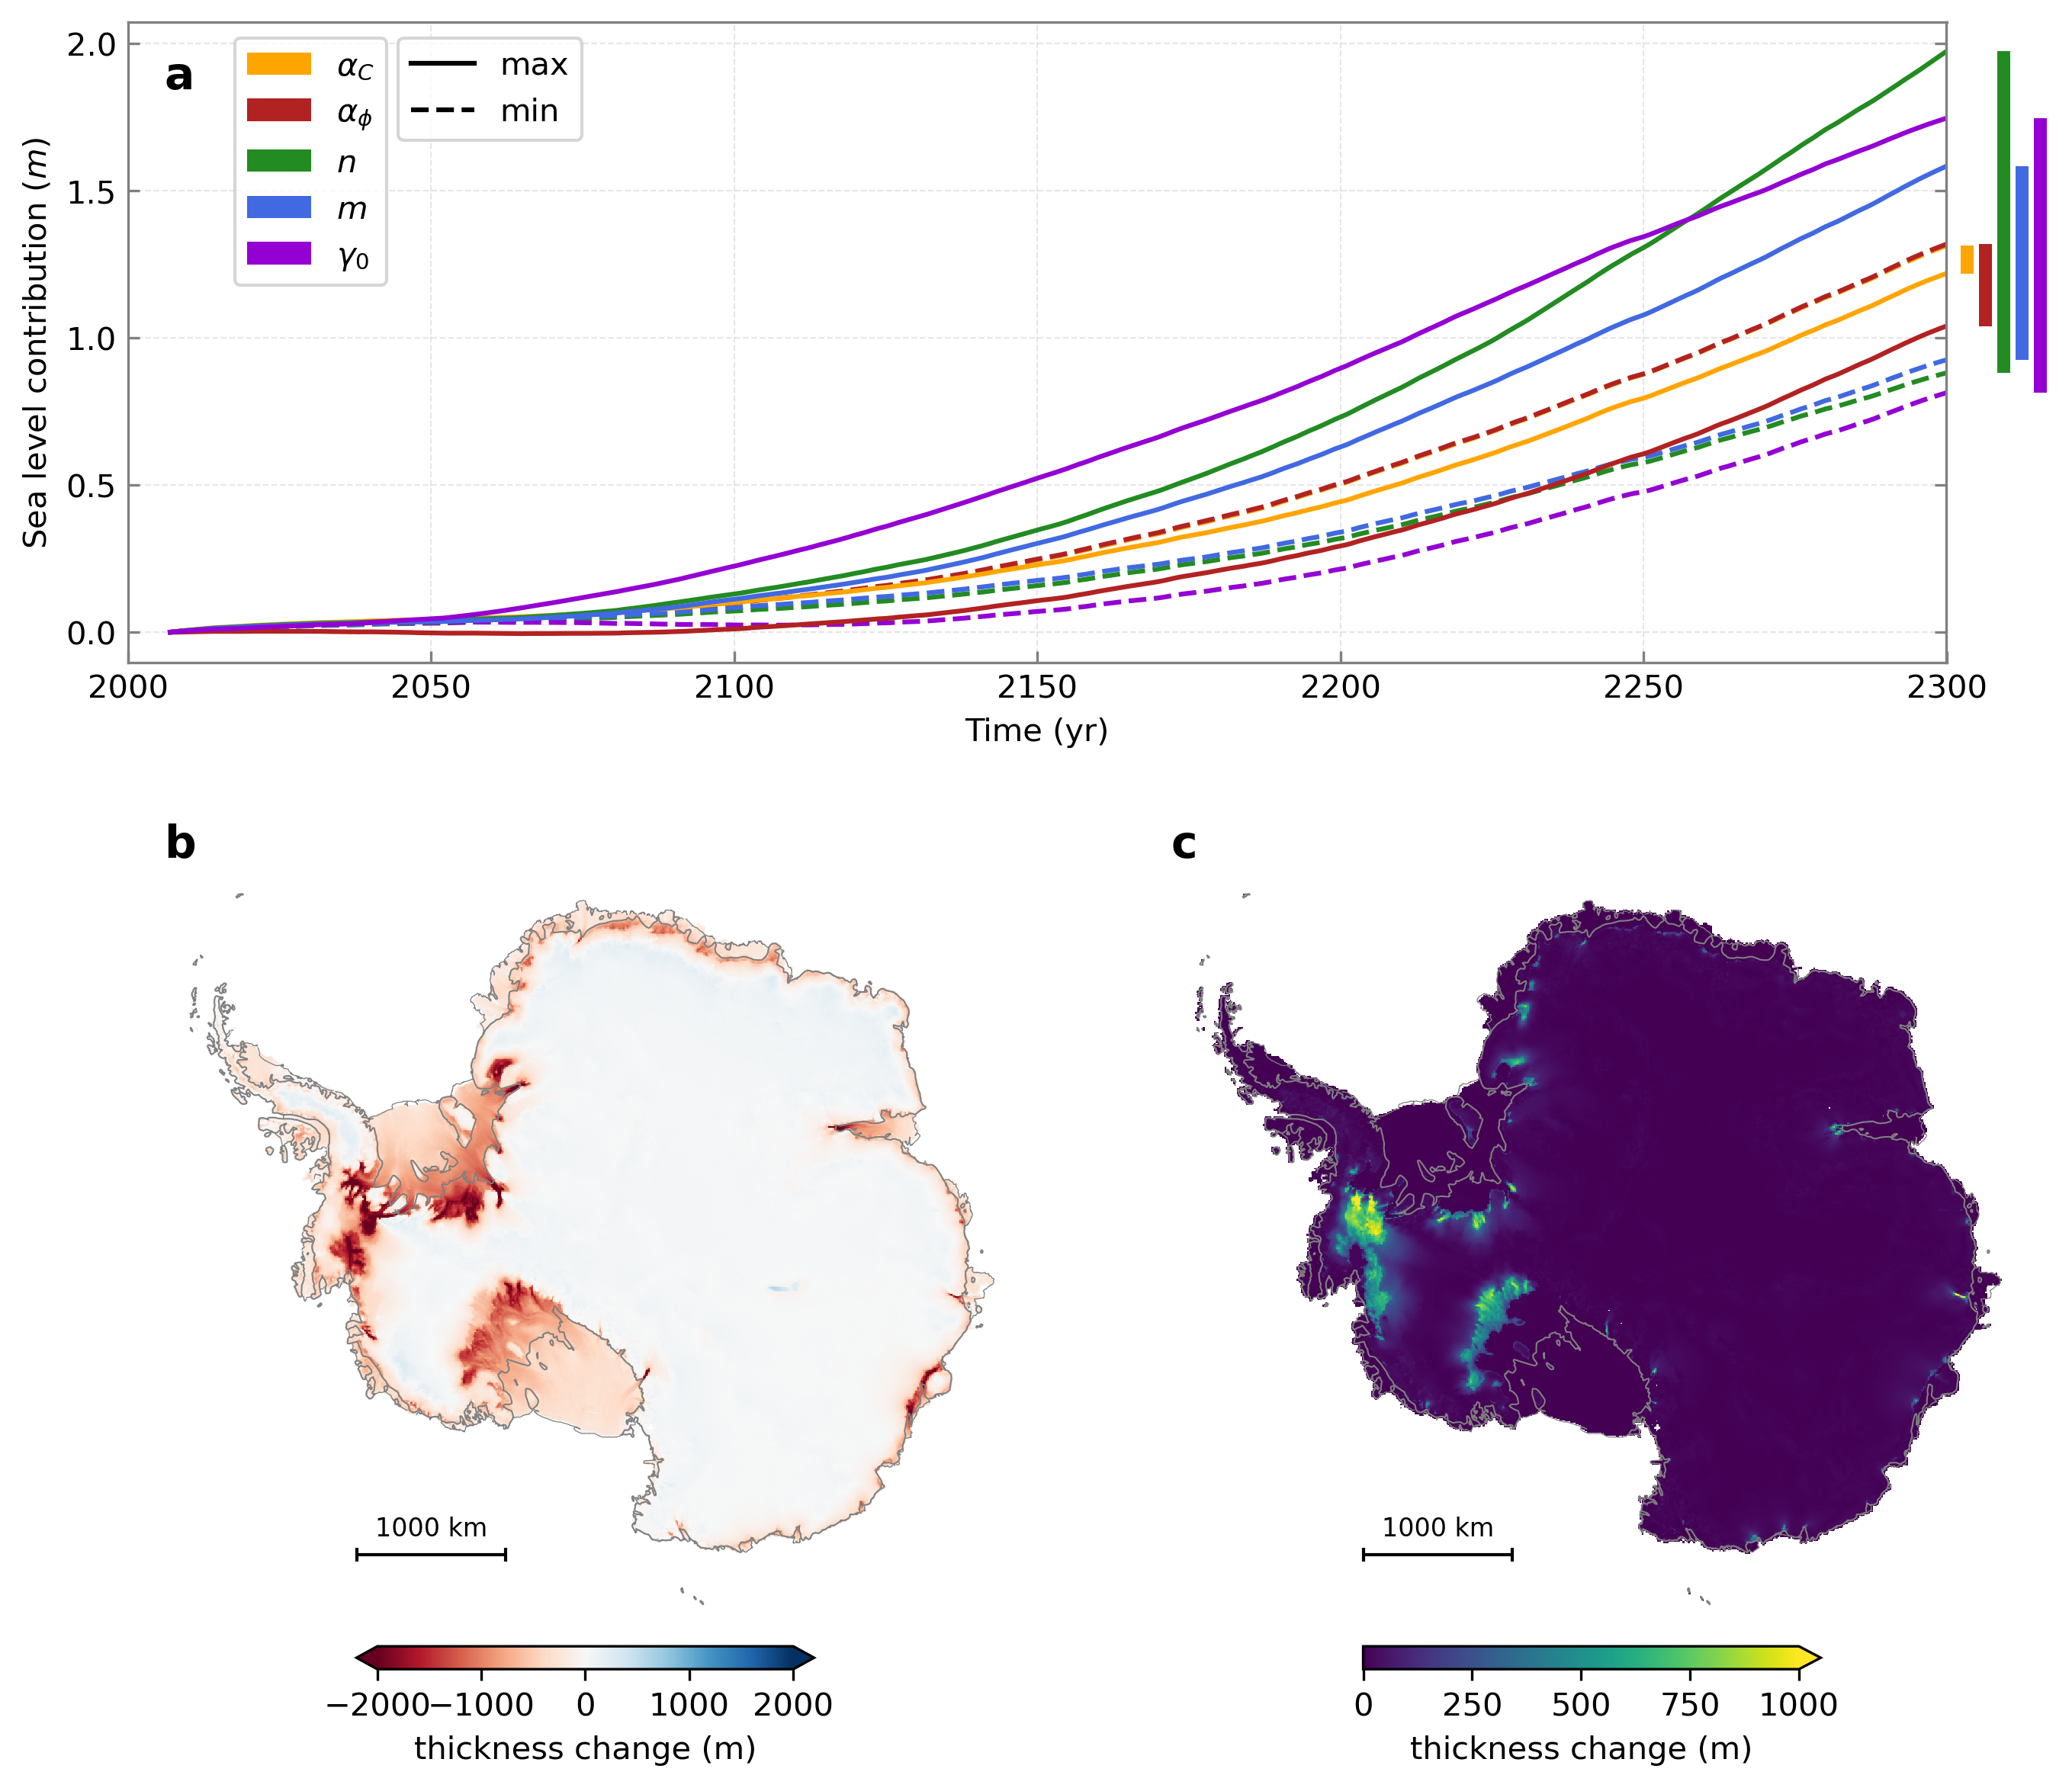

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import geopandas as gpd

fig, ax_top, ax_bar, ax_bl, ax_br, cax_bl, cax_br = make_figure(height_ratio=0.7, ax_size=4, cb_pad=-0.2, hspace=0.5, bar_width=0.4, bar_pad=0.05)

odd = sle.sel(run=[1, 3, 5, 7, 9])
even = sle.sel(run=[0, 2, 4, 6, 8])
colors = ["orange", "firebrick", "forestgreen", "royalblue", "darkviolet"]

for run in even.run:
    ts = even.sel(run=run)
    ts.plot(ax=ax_top, color=colors[int(run)], label=f"run {run.values}", linestyle="--")

for run in odd.run:
    ts = odd.sel(run=run)
    ts.plot(ax=ax_top, color=colors[int(run)], label=f"run {run.values}")

params = [r"$\alpha_{C}$", r"$\alpha_{\phi}$", "$n$", "$m$", "$\gamma_0$"]
colors = ["orange", "firebrick", "forestgreen", "royalblue", "darkviolet"]

# first legend (patches)
handles1 = [Patch(facecolor=c, label=p) for c, p in zip(colors, params)]
legend1 = ax_top.legend(handles=handles1, loc='upper left', bbox_to_anchor=(0.05, 1))
ax_top.add_artist(legend1)  # keep it, since the next legend() call would otherwise replace it

# second legend (line styles)
handles2 = [
    Line2D([0], [0], color='black', linestyle='-', label='max'),
    Line2D([0], [0], color='black', linestyle='--', label='min'),
]
ax_top.legend(handles=handles2, loc='upper left', bbox_to_anchor=(0.14, 1))

param_indices = range(5)

for i in param_indices:
    min_val = even.sel(run=i).isel(time=-1).values
    max_val = odd.sel(run=i).isel(time=-1).values
    ax_bar.bar(i, max_val - min_val, bottom=min_val, width=0.7, color=colors[i])

ax_bar.set_xlim(-0.5, len(params) - 0.5)
ax_bar.set_ylim(ax_top.get_ylim())
ax_bar.set_axis_off()

ax_top.set_xlim(2000, 2300)
ax_top.set_xlabel("Time (yr)")
ax_top.set_ylabel("Sea level contribution ($m$)")
ax_top.set_yticks(list(np.arange(0, 2.1, 0.5)))

ax_top.tick_params(axis='y', which='both', left=True, right=True, labelleft=True, labelright=False, direction="in", color="grey")
ax_top.tick_params(axis="x", direction="in", color="grey")
ax_top.spines['bottom'].set_color('grey')
ax_top.spines['left'].set_color('grey')
ax_top.spines["right"].set_color('grey')
ax_top.spines["top"].set_color('grey')
ax_top.grid(color="grey", alpha=0.2, linewidth=0.5, linestyle="--")

# --- inset 2100 projections ---

# axin = ax_top.inset_axes([0.1, 0.45, 0.3, 0.5])
# for run in even.run:
#     ts = even.sel(run=run, time=slice(2000, 2100))
#     axin.plot(ts.time, ts, color=colors[int(run)], linestyle="--")
# for run in odd.run:
#     ts = odd.sel(run=run, time=slice(2000, 2100))
#     axin.plot(ts.time, ts, color=colors[int(run)])
# axin.set_xlim(2000, 2100)

# axbarin = ax_top.inset_axes([0.401, 0.45, 0.05, 0.5], sharey=axin)
# for i in param_indices:
#     min_val = even.sel(run=i).sel(time=2100).values
#     max_val = odd.sel(run=i).sel(time=2100).values
#     axbarin.bar(i, max_val - min_val, bottom=min_val, width=0.7, color=colors[i])
# axbarin.set_axis_off()

kw = dict(central_latitude=-90, central_longitude=0, true_scale_latitude=-70)
proj = ccrs.Stereographic(**kw)

x = avg.x
y = avg.y
x = x-x.mean()
y = y-y.mean()
pcm = ax_bl.pcolormesh(x, y, avg, cmap="RdBu", vmin=-2000, vmax=2000, transform=proj, rasterized=True)
fig.colorbar(pcm, cax=cax_bl, location="bottom", ticks=[-2000, -1000, 0, 1000, 2000], pad=-0.1, shrink=0.5, extend="both", label="thickness change (m)")
pcm = ax_br.pcolormesh(x, y, std, cmap="viridis", vmin=0, vmax=1000, transform=proj, rasterized=True)
fig.colorbar(pcm, cax=cax_br, location="bottom", extend="max", label="thickness change (m)")

gdf = gpd.read_file('/Users/jonniebarnsley/Downloads/add_coastline_medium_res_line_v7_12.shp/add_coastline_medium_res_line_v7_12.shp')
outer = gdf[gdf.surface.isin([#'ice coastline', 'rock coastline',
                              'ice shelf and front'])]
add_crs = ccrs.SouthPolarStereo(true_scale_latitude=-71)

for ax in [ax_bl, ax_br]:
    ax.add_geometries(outer.geometry, crs=add_crs, edgecolor='grey',
                      facecolor='none', linewidth=0.3, zorder=102)
    ax.coastlines(linewidth=0.5, color="grey")
    ax.set_axis_off()

def add_scale_bar(ax, length_km=100, loc=(0.08, 0.08), color='black', lw=3, cap_frac=0.15):
    x0, x1, y0, y1 = ax.get_extent(ax.projection)
    length_m = length_km * 1000
    x_start = x0 + loc[0] * (x1 - x0)
    x_end = x_start + length_m
    y_pos = y0 + loc[1] * (y1 - y0)

    cap_h = cap_frac * (y1 - y0) * 0.05  # half-height of the end caps

    # main bar
    ax.plot([x_start, x_end], [y_pos, y_pos],
            color=color, lw=lw, transform=ax.projection, solid_capstyle='butt')
    # end caps (perpendicular)
    ax.plot([x_start, x_start], [y_pos - cap_h, y_pos + cap_h],
            color=color, lw=lw, transform=ax.projection, solid_capstyle='butt')
    ax.plot([x_end, x_end], [y_pos - cap_h, y_pos + cap_h],
            color=color, lw=lw, transform=ax.projection, solid_capstyle='butt')

    ax.text(x_start + length_m/2, y_pos + 0.015*(y1 - y0), f"{length_km} km",
            transform=ax.projection, ha='center', va='bottom', fontsize=8, color=color)


add_scale_bar(ax_bl, length_km=1000, loc=(0.25, 0.15), lw=1)
add_scale_bar(ax_br, length_km=1000, loc=(0.25, 0.15), lw=1)


ax_top.text(0.02, 0.95, "a", transform=ax_top.transAxes, fontsize=14,
            verticalalignment='top', horizontalalignment='left', fontweight='bold')

for ax, letter in zip([ax_bl, ax_br], "bc"):
    ax.text(0.04, 0.95, letter, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', horizontalalignment='left', fontweight='bold')
    
plt.savefig("papers/inversion_sensitivity/figures/timeseries.pdf", bbox_inches="tight", dpi=300)

In [ ]:
minsle = sle.sel(time=2300).min()
maxsle = sle.sel(time=2300).max()
print(f"min sle: {minsle.values:.3f} m, max sle: {maxsle.values:.3f} m")

min sle: 0.814 m, max sle: 1.974 m


In [ ]:
thkdir = path / "combined"
files = list(thkdir.glob("*.nc"))
ds = xr.open_mfdataset(files, combine="nested", concat_dim="run", parallel=True)
thk = ds.thickness
initthk = thk.isel(time=0, run=0).compute()
dthk = thk.isel(time=-1) - thk.isel(time=0)
odd = dthk.sel(run=[1, 3, 5, 7, 9])
odd = odd.where(initthk > 0)
odd = odd.compute()

In [ ]:
thkdir = path / "combined"
files = list(thkdir.glob("*.nc"))
ds = xr.open_mfdataset(files, combine="nested", concat_dim="run", parallel=True)
thk = ds.thickness
avg = thk.mean(dim="run").compute()

In [ ]:
thkdir = path / "combined"
files = list(thkdir.glob("*.nc"))
ds = xr.open_mfdataset(files, combine="nested", concat_dim="run", parallel=True)
thk = ds.thickness
ice_free = thk < 20
ever_ice_free = ice_free.any(dim="time")
first_idx = ice_free.argmax(dim="time")  # first True; 0 if never True

year_ice_free = thk.time.isel(time=first_idx)
year_ice_free = year_ice_free.where(ever_ice_free)  # NaN where never ice-free
mean = year_ice_free.mean(dim="run").compute()
std = year_ice_free.std(dim="run").compute()

# fig, ax = plt.subplots()
# cf = ax.contourf(avg.x, avg.y, year_ice_free, levels=np.arange(2000, 2301, 100),cmap="viridis")
# fig.colorbar(cf, ax=ax, label="Year ice-free")


NameError: name 'path' is not defined

In [ ]:
thkdir = path / "combined"
files = list(thkdir.glob("*.nc"))
ds = xr.open_mfdataset(files, combine="nested", concat_dim="run", parallel=True)
thk = ds.thickness
run9 = thk.sel(run=9).compute()
run8 = thk.sel(run=8).compute()

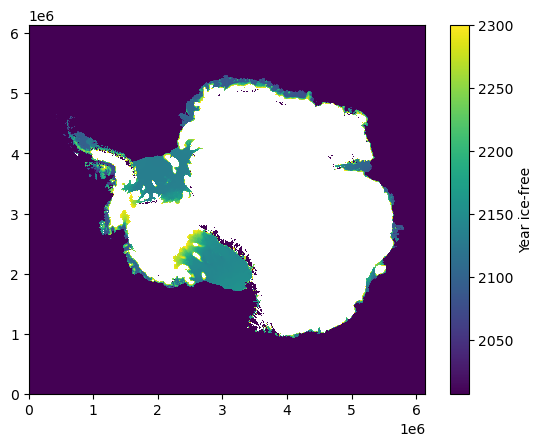

In [ ]:
ice_free = run9 < 50
ever_ice_free = ice_free.any(dim="time")
first_idx = ice_free.argmax(dim="time")  # first True; 0 if never True

year_ice_free = avg.time.isel(time=first_idx)
year_ice_free9 = year_ice_free.where(ever_ice_free)  # NaN where never ice-free

fig, ax = plt.subplots()
cf = ax.pcolormesh(avg.x, avg.y, year_ice_free9,cmap="viridis")
fig.colorbar(cf, ax=ax, label="Year ice-free")

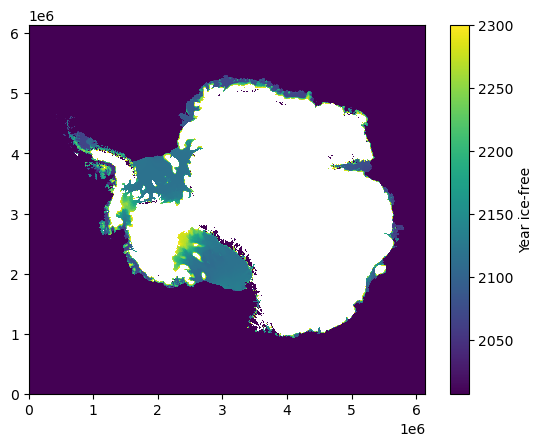

In [ ]:
ice_free = run8 < 50
ever_ice_free = ice_free.any(dim="time")
first_idx = ice_free.argmax(dim="time")  # first True; 0 if never True

year_ice_free = avg.time.isel(time=first_idx)
year_ice_free8 = year_ice_free.where(ever_ice_free)  # NaN where never ice-free

fig, ax = plt.subplots()
cf = ax.pcolormesh(avg.x, avg.y, year_ice_free8,cmap="viridis")
fig.colorbar(cf, ax=ax, label="Year ice-free")

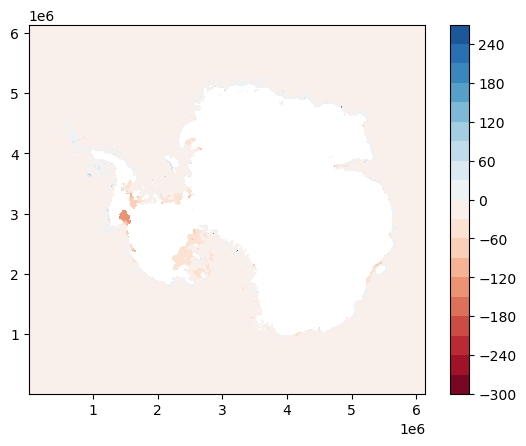

In [ ]:
diff = year_ice_free8 - year_ice_free9
im = plt.contourf(avg.x, avg.y, diff, levels=np.arange(-300, 300, 30), cmap="RdBu", vmin=-300, vmax=300)
plt.colorbar(im)